In [1]:
# 1. Environment Setup & Auto-Reload
%load_ext autoreload
%autoreload 2

import torch
# Import our new modules
from config import Config
from base_dataset import BaseConceptDataset
from data_loaders import Derm7ptDataset, HAM10000Dataset

print(f"Using Device: {Config.DEVICE}")
print(f"Active Dataset Dimensions: {Config.get_active_concept_dims()}")
print("Architecture modules successfully linked!")

Using Device: cpu
Active Dataset Dimensions: [2, 2, 2, 2, 2, 3, 2]
Architecture modules successfully linked!


In [2]:
# Cell 2: Architecture & Data Loader Integration Test

# 1. Test Data Loaders
from data_loaders import Derm7ptDataset, HAM10000Dataset
print("Data Loaders successfully imported!")

# 2. Test Dynamic Model
from models import GatedHybridCBM
from config import Config

model = GatedHybridCBM(
    concept_dims=Config.get_active_concept_dims(),
    backbone=Config.BACKBONE,
    feat_proj_dim=Config.FEAT_PROJ_DIM,
    hidden=Config.HIDDEN_DIM,
    dropout=Config.DROPOUT
).to(Config.DEVICE)

print(f"Model successfully built on {Config.DEVICE}!")
print(f"Number of Concept Heads auto-generated: {len(model.concept_heads)}")

Data Loaders successfully imported!
Model successfully built on cpu!
Number of Concept Heads auto-generated: 7


In [3]:
# Cell 3: Install Lightning & Metrics
!pip install -q pytorch-lightning torchmetrics
print("Libraries installed!")

Libraries installed!



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# Cell 4: Training Engine Test
from engine import CBM_System

# Wrap our previously built model inside the Lightning Engine
lightning_system = CBM_System(model, Config)

print("PyTorch Lightning Engine successfully initialized")
print(f"Tracking Metrics: Accuracy, F1 Score, AUC")

PyTorch Lightning Engine successfully initialized
Tracking Metrics: Accuracy, F1 Score, AUC


In [5]:
# Cell 5: Dry Run
import pandas as pd
import pytorch_lightning as pl
from torch.utils.data import DataLoader
from torchvision import transforms

from config import Config
from data_loaders import Derm7ptDataset
from models import GatedHybridCBM
from engine import CBM_System

print("Building Architecture...")
print("\n")
model = GatedHybridCBM(
    concept_dims=Config.get_active_concept_dims(),
    backbone=Config.BACKBONE,
    feat_proj_dim=Config.FEAT_PROJ_DIM,
    hidden=Config.HIDDEN_DIM,
    dropout=Config.DROPOUT
)
lightning_system = CBM_System(model, Config)

dummy_data = pd.DataFrame({
    'image_path': ['fake1.jpg', 'fake2.jpg', 'fake3.jpg', 'fake4.jpg'],
    'diagnosis': ['melanoma', 'nevus', 'melanoma', 'seborrheic_keratosis'],
    'pigment_network': [1, 0, 1, -1],     
    'streaks': [0, 0, 1, 0],
    'pigmentation': [1, 1, 1, 0],
    'regression_structures': [0, 0, 1, -1],
    'dots_and_globules': [1, 0, 1, 0],
    'blue_whitish_veil': [0, 0, 2, -1],   # This head has 3 classes (0, 1, 2), so this is safe!
    'vascular_structures': [0, 1, 1, 0]   # FIX: This head only has 2 classes (0, 1). No more 2s!
})

basic_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

dummy_dataset = Derm7ptDataset(metadata_df=dummy_data, image_dir="./", transforms=basic_transform)
train_loader = DataLoader(dummy_dataset, batch_size=2, shuffle=True)
val_loader = DataLoader(dummy_dataset, batch_size=2, shuffle=False)

trainer = pl.Trainer(
    fast_dev_run=True, 
    accelerator="cpu",
    enable_checkpointing=False,
    logger=False
)

print("Initiating Dry Run Engine...")
print("\n")
trainer.fit(lightning_system, train_dataloaders=train_loader, val_dataloaders=val_loader)

Building Architecture...




GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Running in `fast_dev_run` mode: will run the requested loop using 1 batch(es). Logging and checkpointing is suppressed.


Initiating Dry Run Engine...




┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type                   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model           │ GatedHybridCBM         │ 26.7 M │ train │     0 │
│ 1 │ concept_loss_fn │ MaskedFocalConceptLoss │      0 │ train │     0 │
│ 2 │ task_loss_fn    │ BinaryFocalLoss        │      0 │ train │     0 │
│ 3 │ val_acc         │ BinaryAccuracy         │      0 │ train │     0 │
│ 4 │ val_f1          │ BinaryF1Score          │      0 │ train │     0 │
│ 5 │ val_auc         │ BinaryAUROC            │      0 │ train │     0 │
└───┴─────────────────┴────────────────────────┴────────┴───────┴───────┘

Trainable params: 26.7 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 26.7 M                                                                                               
Total estimated model params size (MB): 106.678                                                                    
Modules in train mode: 791                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

C:\Users\prune\miniconda3\envs\tf_env\lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\prune\miniconda3\envs\tf_env\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
C:\Users\prune\miniconda3\envs\tf_env\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
`Trainer.fit` stopped: `max_steps=1` reached.


In [2]:
# Cell 6: System Reactivation & Deterministic Overfit Test
%load_ext autoreload
%autoreload 2

import os
import sys
import pandas as pd
import pytorch_lightning as pl
from torch.utils.data import DataLoader
from torchvision import transforms

# Force pathing
sys.path.append(os.path.abspath('.'))

from config import Config
from data_loaders import Derm7ptDataset
from models import GatedHybridCBM
from engine import CBM_System

# ---------------------------------------------------------
# 1. HOOKING UP THE REAL DATA
# ---------------------------------------------------------
DATA_DIR = r"C:\Users\prune\OneDrive\Desktop\XAI CBM Coalations\derm7pt"

# ---> THE FIX: Added the "meta" subfolder to the path <---
META_CSV = os.path.join(DATA_DIR, "meta", "meta.csv") 

# Assuming your images are still in the main 'images' folder
IMAGE_DIR = os.path.join(DATA_DIR, "images")  

print("Loading Real Metadata...")
real_df = pd.read_csv(META_CSV)

# ---------------------------------------------------------
# 2. WAKING UP THE BRAIN
# ---------------------------------------------------------
print("Waking up the Brain...")
model = GatedHybridCBM(
    concept_dims=Config.get_active_concept_dims(),
    backbone=Config.BACKBONE,
    feat_proj_dim=Config.FEAT_PROJ_DIM,
    hidden=Config.HIDDEN_DIM,
    dropout=Config.DROPOUT
)
lightning_system = CBM_System(model, Config)

# ---------------------------------------------------------
# 3. DATA PIPELINE (1 Batch)
# ---------------------------------------------------------
basic_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

real_dataset = Derm7ptDataset(metadata_df=real_df, image_dir=IMAGE_DIR, transforms=basic_transform)

# We only need a tiny batch of 8 images for the overfit test
train_loader = DataLoader(real_dataset, batch_size=8, shuffle=True) 

# ---------------------------------------------------------
# 4. THE OVERFIT ENGINE
# ---------------------------------------------------------
trainer = pl.Trainer(
    max_epochs=50, 
    overfit_batches=1, # Lightning Magic: Locks onto 1 batch and hammers it
    accelerator="cpu", 
    enable_checkpointing=False,
    logger=False
)

print("Initiating Deterministic Overfit Test...")
trainer.fit(lightning_system, train_dataloaders=train_loader)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loading Real Metadata...
Waking up the Brain...


GPU available: False, used: False
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
`Trainer(overfit_batches=1)` was configured so 1 batch will be used.
`Trainer(overfit_batches=1)` was configured so 1 batch will be used.


Initiating Deterministic Overfit Test...


C:\Users\prune\miniconda3\envs\tf_env\lib\site-packages\pytorch_lightning\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type                   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model           │ GatedHybridCBM         │ 26.7 M │ train │     0 │
│ 1 │ concept_loss_fn │ MaskedFocalConceptLoss │      0 │ train │     0 │
│ 2 │ task_loss_fn    │ BinaryFocalLoss        │      0 │ train │     0 │
│ 3 │ val_acc         │ BinaryAccuracy         │      0 │ train │     0 │
│ 4 │ val_f1          │ BinaryF1Score          │      0 │ train │     0 │
│ 5 │ val_auc         │ BinaryAUROC            │      0 │ train │     0 │
└───┴─────────────────┴────────────────────────┴────────┴───────┴───────┘

Trainable params: 26.7 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 26.7 M                                                                                               
Total estimated model params size (MB): 106.678                                                                    
Modules in train mode: 791                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

C:\Users\prune\miniconda3\envs\tf_env\lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\prune\miniconda3\envs\tf_env\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:260: You requested to overfit but enabled train dataloader shuffling. We are turning off the train dataloader shuffling for you.
C:\Users\prune\miniconda3\envs\tf_env\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Output()

`Trainer.fit` stopped: `max_epochs=50` reached.
`Trainer.fit` stopped: `max_epochs=50` reached.


In [1]:
# Cell 7: The Local Validation & XAI
%load_ext autoreload
%autoreload 2

import os
import sys
import torch
import pandas as pd
import pytorch_lightning as pl
from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split

sys.path.append(os.path.abspath('.'))

from config import Config
from data_loaders import Derm7ptDataset
from models import GatedHybridCBM
from engine import CBM_System

# 1. Load Data & Create a Local Subset
DATA_DIR = r"C:\Users\prune\OneDrive\Desktop\XAI CBM Coalations\derm7pt"
META_CSV = os.path.join(DATA_DIR, "meta", "meta.csv") 
IMAGE_DIR = os.path.join(DATA_DIR, "images")  

full_df = pd.read_csv(META_CSV)

# Let's take 200 random images for the local CPU test to avoid melting your laptop
subset_df = full_df.sample(n=200, random_state=42)

# Create a strict 80/20 Train-Validation Split
train_df, val_df = train_test_split(subset_df, test_size=0.2, stratify=subset_df['diagnosis'], random_state=42)
print(f"Dataset Split: {len(train_df)} Train images, {len(val_df)} Val images.")

# 2. Build the Pipeline
basic_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_dataset = Derm7ptDataset(metadata_df=train_df, image_dir=IMAGE_DIR, transforms=basic_transform)
val_dataset = Derm7ptDataset(metadata_df=val_df, image_dir=IMAGE_DIR, transforms=basic_transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True) 
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

# 3. Initialize the Brain & Engine
model = GatedHybridCBM(
    concept_dims=Config.get_active_concept_dims(),
    backbone=Config.BACKBONE,
    feat_proj_dim=Config.FEAT_PROJ_DIM,
    hidden=Config.HIDDEN_DIM,
    dropout=Config.DROPOUT
)
lightning_system = CBM_System(model, Config)

# 4. Run the Mini-Epochs
trainer = pl.Trainer(
    max_epochs=3, # Just 3 epochs to verify metric calculation
    accelerator="cpu", 
    enable_checkpointing=False,
    logger=False
)

print("\nInitiating Local Validation Suite...")
trainer.fit(lightning_system, train_dataloaders=train_loader, val_dataloaders=val_loader)

# ---------------------------------------------------------
# 5. POST-HOC XAI AUDIT (The Alpha Gate)
# ---------------------------------------------------------
print("\nExecuting Post-Hoc XAI Audit...")
lightning_system.eval()
with torch.no_grad():
    # Grab one batch from validation
    val_images, val_concepts, val_masks, val_labels = next(iter(val_loader))
    
    # Push it through the model
    _, y_logit, alpha = lightning_system(val_images)
    preds = torch.sigmoid(y_logit)
    
    print("\n--- Model Reasoning Audit (Batch of 8) ---")
    for i in range(len(val_labels)):
        actual = "Melanoma" if val_labels[i].item() == 1.0 else "Other"
        pred_prob = preds[i].item() * 100
        alpha_val = alpha[i].item()
        
        print(f"Image {i+1}: Ground Truth = {actual} | Predicted Melanoma Prob = {pred_prob:.1f}%")
        print(f"   -> Alpha Gate (Concept Reliance): {alpha_val:.3f} (1.0 = 100% reliant on clinical concepts)")

Dataset Split: 160 Train images, 40 Val images.


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



Initiating Local Validation Suite...


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type                   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model           │ GatedHybridCBM         │ 26.7 M │ train │     0 │
│ 1 │ concept_loss_fn │ MaskedFocalConceptLoss │      0 │ train │     0 │
│ 2 │ task_loss_fn    │ BinaryFocalLoss        │      0 │ train │     0 │
│ 3 │ val_acc         │ BinaryAccuracy         │      0 │ train │     0 │
│ 4 │ val_f1          │ BinaryF1Score          │      0 │ train │     0 │
│ 5 │ val_auc         │ BinaryAUROC            │      0 │ train │     0 │
│ 6 │ val_precision   │ BinaryPrecision        │      0 │ train │     0 │
│ 7 │ val_recall      │ BinaryRecall           │      0 │ train │     0 │
└───┴─────────────────┴────────────────────────┴────────┴───────┴───────┘

Trainable params: 26.7 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 26.7 M                                                                                               
Total estimated model params size (MB): 106.678                                                                    
Modules in train mode: 793                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

C:\Users\prune\miniconda3\envs\tf_env\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434:
The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.

C:\Users\prune\miniconda3\envs\tf_env\lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: No 
positive samples in targets, true positive value should be meaningless. Returning zero tensor in true positive 
score
  warnings.warn(*args, **kwargs)

C:\Users\prune\miniconda3\envs\tf_env\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434:
The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.

`Trainer.fit` stopped: `max_epochs=3` reached.



Executing Post-Hoc XAI Audit...

--- Model Reasoning Audit (Batch of 8) ---
Image 1: Ground Truth = Other | Predicted Melanoma Prob = 50.5%
   -> Alpha Gate (Concept Reliance): 0.484 (1.0 = 100% reliant on clinical concepts)
Image 2: Ground Truth = Other | Predicted Melanoma Prob = 50.5%
   -> Alpha Gate (Concept Reliance): 0.484 (1.0 = 100% reliant on clinical concepts)
Image 3: Ground Truth = Other | Predicted Melanoma Prob = 50.5%
   -> Alpha Gate (Concept Reliance): 0.484 (1.0 = 100% reliant on clinical concepts)
Image 4: Ground Truth = Other | Predicted Melanoma Prob = 50.5%
   -> Alpha Gate (Concept Reliance): 0.484 (1.0 = 100% reliant on clinical concepts)
Image 5: Ground Truth = Other | Predicted Melanoma Prob = 50.5%
   -> Alpha Gate (Concept Reliance): 0.484 (1.0 = 100% reliant on clinical concepts)
Image 6: Ground Truth = Other | Predicted Melanoma Prob = 50.5%
   -> Alpha Gate (Concept Reliance): 0.484 (1.0 = 100% reliant on clinical concepts)
Image 7: Ground Truth = Other

Sweeping Validation Set for XAI Analysis...


C:\Users\prune\AppData\Local\Temp\ipykernel_11748\3390184872.py:48: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(other_alphas, fill=True, color='steelblue', label='Other (Actual)', ax=axes[1])
C:\Users\prune\AppData\Local\Temp\ipykernel_11748\3390184872.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


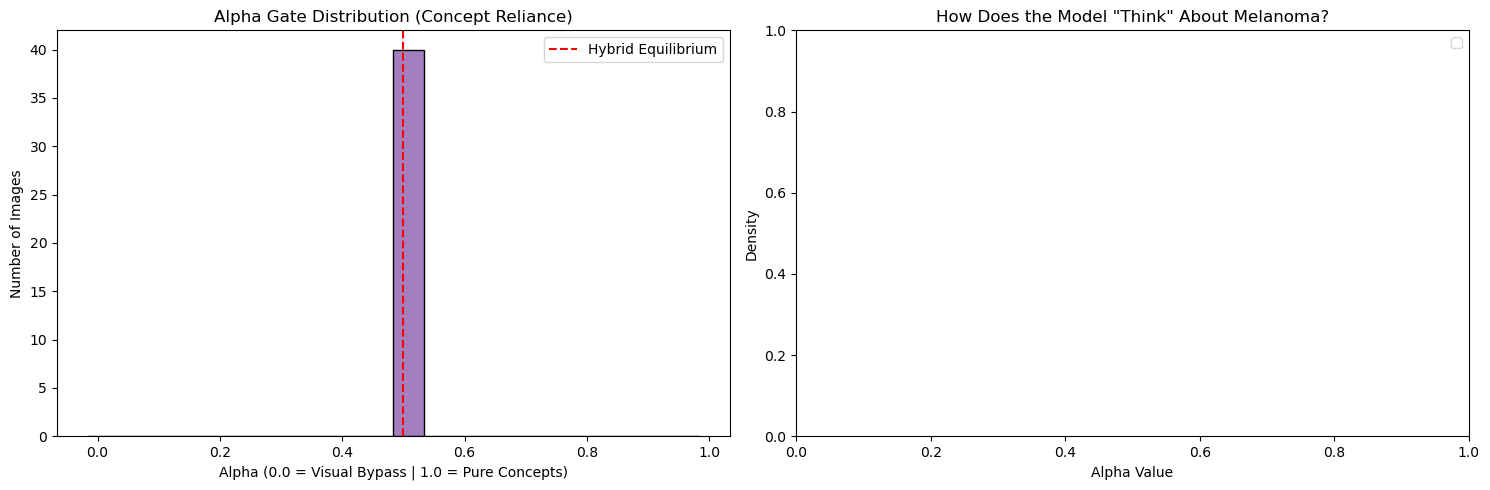

In [2]:
# Cell 8: Post-Hoc XAI Visualization
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_model_reasoning(lightning_sys, dataloader):
    lightning_sys.eval()
    all_alphas = []
    all_preds = []
    all_labels = []
    
    print("Sweeping Validation Set for XAI Analysis...")
    with torch.no_grad():
        for images, concepts, masks, labels in dataloader:
            _, y_logit, alpha = lightning_sys(images)
            preds = torch.sigmoid(y_logit)
            
            all_alphas.extend(alpha.numpy())
            all_preds.extend(preds.numpy())
            all_labels.extend(labels.numpy())

    all_alphas = np.array(all_alphas)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # ---------------------------------------------------------
    # Plot 1: Alpha Gate Distribution (Concept vs Visual Reliance)
    # ---------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    sns.histplot(all_alphas, bins=20, kde=True, ax=axes[0], color='indigo')
    axes[0].set_title('Alpha Gate Distribution (Concept Reliance)')
    axes[0].set_xlabel('Alpha (0.0 = Visual Bypass | 1.0 = Pure Concepts)')
    axes[0].set_ylabel('Number of Images')
    axes[0].axvline(0.5, color='red', linestyle='--', label='Hybrid Equilibrium')
    axes[0].legend()

    # ---------------------------------------------------------
    # Plot 2: Diagnosis vs. Concept Reliance
    # ---------------------------------------------------------
    # Separate Alphas based on True Diagnosis
    melanoma_alphas = all_alphas[all_labels == 1]
    other_alphas = all_alphas[all_labels == 0]
    
    sns.kdeplot(melanoma_alphas, fill=True, color='crimson', label='Melanoma (Actual)', ax=axes[1])
    if len(other_alphas) > 0:
        sns.kdeplot(other_alphas, fill=True, color='steelblue', label='Other (Actual)', ax=axes[1])
        
    axes[1].set_title('How Does the Model "Think" About Melanoma?')
    axes[1].set_xlabel('Alpha Value')
    axes[1].set_ylabel('Density')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

# Execute the visualization
visualize_model_reasoning(lightning_system, val_loader)